     r_A  g_r  n_r  w_r_kJmol
0  0.025  0.0  0.0        NaN
1  0.075  0.0  0.0        NaN
2  0.125  0.0  0.0        NaN
3  0.175  0.0  0.0        NaN
4  0.225  0.0  0.0        NaN


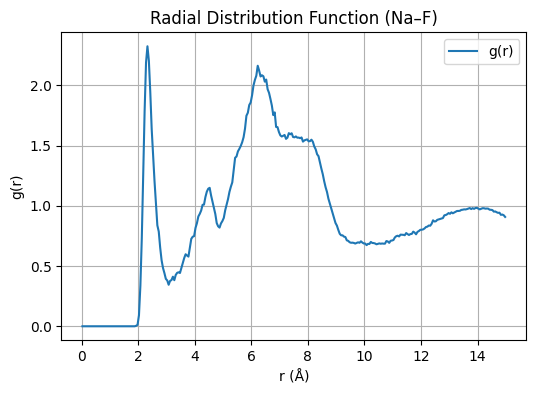

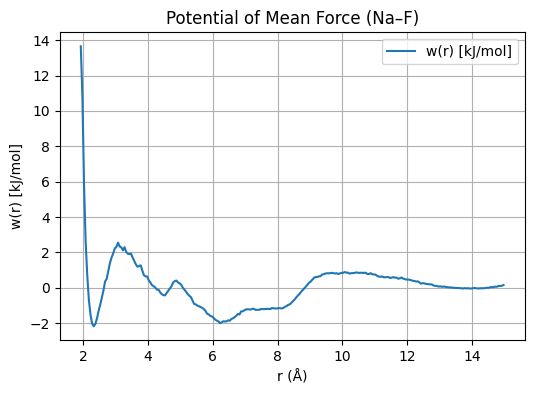

In [1]:
### Na - O solvent 
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("/projects/beye/iamin/rdfs/Archive/rdf_csvs_na_F/RDF_DG_Na-F.csv")

# Preview the data
print(df.head())

# Plot g(r) vs r_A
plt.figure(figsize=(6,4))
plt.plot(df["r_A"], df["g_r"], label="g(r)")
plt.xlabel("r (Å)")
plt.ylabel("g(r)")
plt.title("Radial Distribution Function (Na–F)")
plt.legend()
plt.grid(True)
plt.show()

# Optional: Plot w(r) if you want
plt.figure(figsize=(6,4))
plt.plot(df["r_A"], df["w_r_kJmol"], label="w(r) [kJ/mol]")
plt.xlabel("r (Å)")
plt.ylabel("w(r) [kJ/mol]")
plt.title("Potential of Mean Force (Na–F)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Compute g(r), n(r), and PMF w(r) for Na–P (PF6–) using the FULL trajectory
(no block averaging). Saves one CSV per system.

Outputs (in ./rdf_csvs):
  RDF_<LABEL>_Na-P.csv   with columns:
    r_A, g_r, n_r, w_r_kJmol
"""

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from ase.io.trajectory import Trajectory
from ase.geometry import find_mic
from math import pi

# ─── constants ───────────────────────────────────────────────────────────────
T = 298.15                      # K
RkJ = 8.314462618e-3            # kJ mol^-1 K^-1
r_max, dr = 15.0, 0.05          # Å  ← r_max per your request
bins = np.arange(0.0, r_max + dr, dr)
r_mid = 0.5 * (bins[:-1] + bins[1:])
shell_vol = 4.0/3.0 * pi * (bins[1:]**3 - bins[:-1]**3)

# ─── input: traj paths and solvent labels ────────────────────────────────────
traj_paths = [
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/NPT_sims/md_omol_re5_small_new_1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/solvent_uma_npt/md_omol_dimethylcarbonate_pfactor_0.1_1fs_mask_t_re3_s1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/solvent_uma_npt/md_omol_tetrahydrofuran_pfactor_0.1_1fs_mask_t_re3_s1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/solvent_uma_npt/md_omol_propylene_carbonate_pfactor_0.1_1fs_mask_t_re1_s1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/solvent_uma_npt/md_omol_diglyme_pfactor_0.1_1fs_mask_t_re1_s1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/1M_TGDME_systems/1M_TGDME_systems/md_omol_napf6_tgdme_1m_s1p1.traj",
]
labels = ["DME", "DMC", "THF", "PC", "DG", "TGDME"]

# species to correlate
cation_atom = "Na"
anion_atom  = "O"   # O atoms solvent 

# ─── output dir ──────────────────────────────────────────────────────────────
out_dir = Path("rdf_csvs_na_o")
out_dir.mkdir(parents=True, exist_ok=True)

def compute_rdf_full_traj(traj_path, label):
    """Stream the whole trajectory once; accumulate histogram and densities."""
    traj = Trajectory(traj_path, mode="r")
    if len(traj) == 0:
        raise ValueError(f"{label}: empty trajectory: {traj_path}")

    hist = np.zeros(len(r_mid), dtype=np.float64)
    n_cat_total = 0.0           # total # of cations across all frames
    n_ano_total = 0.0           # total # of anions across all frames
    vol_sum = 0.0               # sum of volumes across frames
    n_frames_used = 0

    for at in tqdm(traj, desc=f"{label}: scanning frames", leave=False):
        syms = at.get_chemical_symbols()
        idx_cat = [i for i, s in enumerate(syms) if s == cation_atom]
        idx_ano = [i for i, s in enumerate(syms) if s == anion_atom]
        if not idx_cat or not idx_ano:
            continue

        pos = at.get_positions()
        pos_cat = pos[idx_cat]
        pos_ano = pos[idx_ano]
        cell, pbc = at.get_cell(), at.get_pbc()

        # accumulate pair distances with MIC
        for rc in pos_cat:
            disp, _ = find_mic(pos_ano - rc, cell, pbc)
            d = np.linalg.norm(disp, axis=1)
            hist += np.histogram(d, bins=bins)[0]

        n_cat_total += float(len(idx_cat))
        n_ano_total += float(len(idx_ano))
        vol_sum += float(at.get_volume())
        n_frames_used += 1

    if n_frames_used == 0:
        raise ValueError(f"{label}: no usable frames found.")

    # average counts per frame (keeps consistency if box or composition fluctuates)
    n_cat_avg = n_cat_total / n_frames_used
    n_ano_avg = n_ano_total / n_frames_used
    vol_avg   = vol_sum / n_frames_used

    if n_cat_avg <= 0 or n_ano_avg <= 0 or vol_avg <= 0:
        raise ValueError(f"{label}: invalid counts/volume (Na={n_cat_avg}, P={n_ano_avg}, V={vol_avg}).")

    # normalize to obtain g(r)
    rho_ano = n_ano_avg / vol_avg                      # Å^-3
    # hist is total counts over all frames; convert to per-cation-per-frame
    counts_per_cat_per_frame = hist / (n_cat_total)    # because n_cat_total = n_cat_avg * n_frames_used
    g_r = counts_per_cat_per_frame / (rho_ano * shell_vol)

    # running coordination number n(r): cumulative neighbors per cation
    n_r = np.cumsum(counts_per_cat_per_frame)

    # PMF: -RT ln g(r); set far-right mean to zero reference; mask non-finite
    with np.errstate(divide="ignore", invalid="ignore"):
        w_r = -RkJ * T * np.log(g_r)
    w_r[~np.isfinite(w_r)] = np.nan
    # zero at the last 10% of the curve (where g ~ 1)
    tail = max(1, int(0.9 * len(w_r)))
    w_r = w_r - np.nanmean(w_r[tail:])

    # save CSV
    df = pd.DataFrame({
        "r_A": r_mid,
        "g_r": g_r,
        "n_r": n_r,
        "w_r_kJmol": w_r
    })
    out_path = out_dir / f"RDF_{label}_Na-O.csv"
    df.to_csv(out_path, index=False)
    return out_path

if __name__ == "__main__":
    written = []
    for path, lab in zip(traj_paths, labels):
        written.append(str(compute_rdf_full_traj(path, lab)))
    print("Wrote CSVs:\n  " + "\n  ".join(written))


In [ ]:
### Plotting 

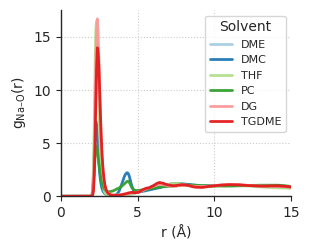

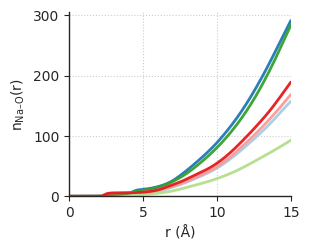

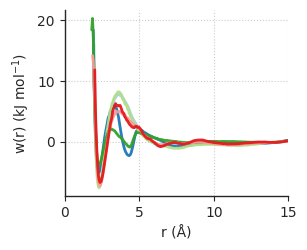

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Styled plots for g(r), n(r), and PMF w(r) from saved CSVs:
  ./rdf_csvs/RDF_<LABEL>_Na-P.csv  with columns: r_A, g_r, n_r, w_r_kJmol
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- where the CSVs live -----------------------------------------------------
in_dir = Path("rdf_csvs_na_o")

# --- Styling and palette -----------------------------------------------------
sns.set_style("ticks")
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["font.family"] = "DejaVu Sans"

# Define order and colors
solvent_order = ["DME", "DMC", "THF", "PC", "DG", "TGDME"]
solvent_colors = sns.color_palette("Paired", len(solvent_order))
solvent_color_map = {solv: solvent_colors[i] for i, solv in enumerate(solvent_order)}
markers = ['o', 's', '^', 'D', 'v', '*']

# --- load all CSVs -----------------------------------------------------------
curves = {}  # curves[tag] = DataFrame with r_A, g_r, n_r, w_r_kJmol
missing = []
for tag in solvent_order:
    f = in_dir / f"RDF_{tag}_Na-O.csv"
    if not f.exists():
        missing.append(tag)
        continue
    df = pd.read_csv(f)
    # basic sanity: ensure expected columns exist
    needed = {"r_A", "g_r", "n_r", "w_r_kJmol"}
    if not needed.issubset(df.columns):
        raise ValueError(f"{f} missing columns. Found {df.columns.tolist()}, need {sorted(needed)}")
    curves[tag] = df

if missing:
    print("Warning: missing CSVs for:", ", ".join(missing))
if not curves:
    raise SystemExit("No CSVs found to plot. Check `in_dir` and file names.")

# X-range for plots (adjust as you like)
x_min, x_max = 0.0, 15.0  # you computed up to 15 Å

# ---------------- RDF g(r) plot ---------------------------------------------
plt.figure(figsize=(3.2, 2.6))
for idx, tag in enumerate(solvent_order):
    if tag not in curves:
        continue
    df = curves[tag]
    plt.plot(
        df["r_A"], df["g_r"],
        label=tag,
        color=solvent_color_map[tag],
        linewidth=2.0,
        marker=markers[idx % len(markers)],
        markevery=25, markersize=0, alpha=0.95
    )

plt.xlabel("r (Å)")
plt.ylabel("g$_{\\mathrm{Na–O}}$(r)")
plt.xlim(x_min, x_max)
plt.ylim(bottom=0)
plt.grid(True, linestyle=":")
plt.legend(title="Solvent", frameon=True, loc="upper right", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig("rdf_Na_O_six_solvents.png", dpi=600)
plt.show()

# -------------- Coordination number n(r) plot --------------------------------
plt.figure(figsize=(3.2, 2.6))
for idx, tag in enumerate(solvent_order):
    if tag not in curves:
        continue
    df = curves[tag]
    plt.plot(
        df["r_A"], df["n_r"],
        label=tag,
        color=solvent_color_map[tag],
        linewidth=2.0,
        marker=markers[idx % len(markers)],
        markevery=25, markersize=0, alpha=0.95
    )

plt.xlabel("r (Å)")
plt.ylabel("n$_{\\mathrm{Na–O}}$(r)")
plt.xlim(x_min, x_max)
plt.ylim(bottom=0)
plt.grid(True, linestyle=":")
# plt.legend(title="Solvent", frameon=True, loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig("nr_Na_O_six_solvents.png", dpi=600)
plt.show()

# --------------------- PMF w(r) plot ----------------------------------------
plt.figure(figsize=(3.2, 2.6))
for idx, tag in enumerate(solvent_order):
    if tag not in curves:
        continue
    df = curves[tag]
    plt.plot(
        df["r_A"], df["w_r_kJmol"],
        label=tag,
        color=solvent_color_map[tag],
        linewidth=2.0,
        linestyle='-',
        marker=markers[idx % len(markers)],
        markevery=25, markersize=0, alpha=0.95
    )

plt.xlabel("r (Å)")
plt.ylabel("w(r) (kJ mol$^{-1}$)")
plt.xlim(x_min, x_max)
plt.grid(True, linestyle=":")
# plt.legend(title="Solvent", frameon=True, loc="lower right")
sns.despine()
plt.tight_layout()
plt.savefig("pmf_Na_O_six_solvents.png", dpi=600)
plt.show()


In [ ]:
### Na - F (PF6) 

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Compute g(r), n(r), and PMF w(r) for Na–P (PF6–) using the FULL trajectory
(no block averaging). Saves one CSV per system.

Outputs (in ./rdf_csvs):
  RDF_<LABEL>_Na-P.csv   with columns:
    r_A, g_r, n_r, w_r_kJmol
"""

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from ase.io.trajectory import Trajectory
from ase.geometry import find_mic
from math import pi

# ─── constants ───────────────────────────────────────────────────────────────
T = 298.15                      # K
RkJ = 8.314462618e-3            # kJ mol^-1 K^-1
r_max, dr = 15.0, 0.05          # Å  ← r_max per your request
bins = np.arange(0.0, r_max + dr, dr)
r_mid = 0.5 * (bins[:-1] + bins[1:])
shell_vol = 4.0/3.0 * pi * (bins[1:]**3 - bins[:-1]**3)

# ─── input: traj paths and solvent labels ────────────────────────────────────
traj_paths = [
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/NPT_sims/md_omol_re5_small_new_1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/solvent_uma_npt/md_omol_dimethylcarbonate_pfactor_0.1_1fs_mask_t_re3_s1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/solvent_uma_npt/md_omol_tetrahydrofuran_pfactor_0.1_1fs_mask_t_re3_s1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/solvent_uma_npt/md_omol_propylene_carbonate_pfactor_0.1_1fs_mask_t_re1_s1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/solvent_uma_npt/md_omol_diglyme_pfactor_0.1_1fs_mask_t_re1_s1p1.traj",
    "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/1M_TGDME_systems/1M_TGDME_systems/md_omol_napf6_tgdme_1m_s1p1.traj",
]
labels = ["DME", "DMC", "THF", "PC", "DG", "TGDME"]

# species to correlate
cation_atom = "Na"
anion_atom  = "F"   # F (PF6– atoms)

# ─── output dir ──────────────────────────────────────────────────────────────
out_dir = Path("rdf_csvs_na_F")
out_dir.mkdir(parents=True, exist_ok=True)

def compute_rdf_full_traj(traj_path, label):
    """Stream the whole trajectory once; accumulate histogram and densities."""
    traj = Trajectory(traj_path, mode="r")
    if len(traj) == 0:
        raise ValueError(f"{label}: empty trajectory: {traj_path}")

    hist = np.zeros(len(r_mid), dtype=np.float64)
    n_cat_total = 0.0           # total # of cations across all frames
    n_ano_total = 0.0           # total # of anions across all frames
    vol_sum = 0.0               # sum of volumes across frames
    n_frames_used = 0

    for at in tqdm(traj, desc=f"{label}: scanning frames", leave=False):
        syms = at.get_chemical_symbols()
        idx_cat = [i for i, s in enumerate(syms) if s == cation_atom]
        idx_ano = [i for i, s in enumerate(syms) if s == anion_atom]
        if not idx_cat or not idx_ano:
            continue

        pos = at.get_positions()
        pos_cat = pos[idx_cat]
        pos_ano = pos[idx_ano]
        cell, pbc = at.get_cell(), at.get_pbc()

        # accumulate pair distances with MIC
        for rc in pos_cat:
            disp, _ = find_mic(pos_ano - rc, cell, pbc)
            d = np.linalg.norm(disp, axis=1)
            hist += np.histogram(d, bins=bins)[0]

        n_cat_total += float(len(idx_cat))
        n_ano_total += float(len(idx_ano))
        vol_sum += float(at.get_volume())
        n_frames_used += 1

    if n_frames_used == 0:
        raise ValueError(f"{label}: no usable frames found.")

    # average counts per frame (keeps consistency if box or composition fluctuates)
    n_cat_avg = n_cat_total / n_frames_used
    n_ano_avg = n_ano_total / n_frames_used
    vol_avg   = vol_sum / n_frames_used

    if n_cat_avg <= 0 or n_ano_avg <= 0 or vol_avg <= 0:
        raise ValueError(f"{label}: invalid counts/volume (Na={n_cat_avg}, P={n_ano_avg}, V={vol_avg}).")

    # normalize to obtain g(r)
    rho_ano = n_ano_avg / vol_avg                      # Å^-3
    # hist is total counts over all frames; convert to per-cation-per-frame
    counts_per_cat_per_frame = hist / (n_cat_total)    # because n_cat_total = n_cat_avg * n_frames_used
    g_r = counts_per_cat_per_frame / (rho_ano * shell_vol)

    # running coordination number n(r): cumulative neighbors per cation
    n_r = np.cumsum(counts_per_cat_per_frame)

    # PMF: -RT ln g(r); set far-right mean to zero reference; mask non-finite
    with np.errstate(divide="ignore", invalid="ignore"):
        w_r = -RkJ * T * np.log(g_r)
    w_r[~np.isfinite(w_r)] = np.nan
    # zero at the last 10% of the curve (where g ~ 1)
    tail = max(1, int(0.9 * len(w_r)))
    w_r = w_r - np.nanmean(w_r[tail:])

    # save CSV
    df = pd.DataFrame({
        "r_A": r_mid,
        "g_r": g_r,
        "n_r": n_r,
        "w_r_kJmol": w_r
    })
    out_path = out_dir / f"RDF_{label}_Na-F.csv"
    df.to_csv(out_path, index=False)
    return out_path

if __name__ == "__main__":
    written = []
    for path, lab in zip(traj_paths, labels):
        written.append(str(compute_rdf_full_traj(path, lab)))
    print("Wrote CSVs:\n  " + "\n  ".join(written))


In [ ]:
### Plotting 

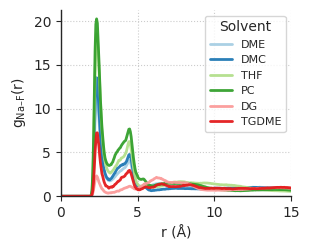

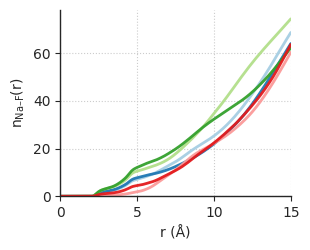

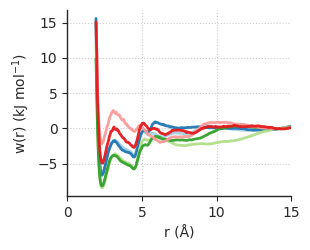

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Styled plots for g(r), n(r), and PMF w(r) from saved CSVs:
  ./rdf_csvs/RDF_<LABEL>_Na-P.csv  with columns: r_A, g_r, n_r, w_r_kJmol
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- where the CSVs live -----------------------------------------------------
in_dir = Path("rdf_csvs_na_f")

# --- Styling and palette -----------------------------------------------------
sns.set_style("ticks")
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["font.family"] = "DejaVu Sans"

# Define order and colors
solvent_order = ["DME", "DMC", "THF", "PC", "DG", "TGDME"]
# Try alternative palettes: "tab10", "Set2", "Paired", "Dark2", etc.
solvent_colors = sns.color_palette("Paired", len(solvent_order))
solvent_color_map = {solv: solvent_colors[i] for i, solv in enumerate(solvent_order)}

markers = ['o', 's', '^', 'D', 'v', '*']

# --- load all CSVs -----------------------------------------------------------
curves = {}  # curves[tag] = DataFrame with r_A, g_r, n_r, w_r_kJmol
missing = []
for tag in solvent_order:
    f = in_dir / f"RDF_{tag}_Na-F.csv"
    if not f.exists():
        missing.append(tag)
        continue
    df = pd.read_csv(f)
    # basic sanity: ensure expected columns exist
    needed = {"r_A", "g_r", "n_r", "w_r_kJmol"}
    if not needed.issubset(df.columns):
        raise ValueError(f"{f} missing columns. Found {df.columns.tolist()}, need {sorted(needed)}")
    curves[tag] = df

if missing:
    print("Warning: missing CSVs for:", ", ".join(missing))
if not curves:
    raise SystemExit("No CSVs found to plot. Check `in_dir` and file names.")

# X-range for plots (adjust as you like)
x_min, x_max = 0.0, 15.0  # you computed up to 15 Å

# ---------------- RDF g(r) plot ---------------------------------------------
plt.figure(figsize=(3.2, 2.6))
for idx, tag in enumerate(solvent_order):
    if tag not in curves:
        continue
    df = curves[tag]
    plt.plot(
        df["r_A"], df["g_r"],
        label=tag,
        color=solvent_color_map[tag],
        linewidth=2.0,
        marker=markers[idx % len(markers)],
        markevery=25, markersize=0, alpha=0.95
    )

plt.xlabel("r (Å)")
plt.ylabel("g$_{\\mathrm{Na–F}}$(r)")
plt.xlim(x_min, x_max)
plt.ylim(bottom=0)
plt.grid(True, linestyle=":")
plt.legend(title="Solvent", frameon=True, loc="upper right", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig("rdf_Na_F_six_solvents.png", dpi=600)
plt.show()

# -------------- Coordination number n(r) plot --------------------------------
plt.figure(figsize=(3.2, 2.6))
for idx, tag in enumerate(solvent_order):
    if tag not in curves:
        continue
    df = curves[tag]
    plt.plot(
        df["r_A"], df["n_r"],
        label=tag,
        color=solvent_color_map[tag],
        linewidth=2.0,
        marker=markers[idx % len(markers)],
        markevery=25, markersize=0, alpha=0.95
    )

plt.xlabel("r (Å)")
plt.ylabel("n$_{\\mathrm{Na–F}}$(r)")
plt.xlim(x_min, x_max)
plt.ylim(bottom=0)
plt.grid(True, linestyle=":")
# plt.legend(title="Solvent", frameon=True, loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig("nr_Na_F_six_solvents.png", dpi=600)
plt.show()

# --------------------- PMF w(r) plot ----------------------------------------
plt.figure(figsize=(3.2, 2.6))
for idx, tag in enumerate(solvent_order):
    if tag not in curves:
        continue
    df = curves[tag]
    plt.plot(
        df["r_A"], df["w_r_kJmol"],
        label=tag,
        color=solvent_color_map[tag],
        linewidth=2.0,
        linestyle='-',
        marker=markers[idx % len(markers)],
        markevery=25, markersize=0, alpha=0.95
    )

plt.xlabel("r (Å)")
plt.ylabel("w(r) (kJ mol$^{-1}$)")
plt.xlim(x_min, x_max)
plt.grid(True, linestyle=":")
# plt.legend(title="Solvent", frameon=True, loc="lower right")
sns.despine()
plt.tight_layout()
plt.savefig("pmf_Na_F_six_solvents.png", dpi=600)
plt.show()
